In [4]:
'''
The purpose of this program is to get insight into how the background data may be behaving.
New models are trained on just the botnet and normal activity from scenarios 1 and 2.
They are then tested on the background data from those scenarios to see how
they categorize them.
'''

'\nThe purpose of this program is to get insight into how the background data may be behaving.\nNew models are trained on just the botnet and normal activity from scenarios 1 and 2.\nThey are then tested on the background data from those scenarios to see how\nthey categorize them.\n'

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import joblib


In [6]:
files = [
    "datasets/scenario1.binetflow",
    "datasets/scenario2.binetflow",

]

# Load and concatenate
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Function to clean label column
def extract_main_label(label):
    if 'Botnet' in label:
        return 'Botnet'
    elif 'Normal' in label:
        return 'Normal'
    elif 'Background' in label:
        return 'Background'
    else:
        return 'Unknown'

# Function to plot the feature importance
def plot_feature_importance(model, model_name, X, top_n=15):
    importances = model.feature_importances_
    feat_names = X.columns
    feat_series = pd.Series(importances, index=feat_names).sort_values(ascending=False)[:top_n]
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=feat_series.values, y=feat_series.index, hue=feat_series.index, legend=False, palette='viridis')
    plt.title(f"Top {top_n} Feature Importances — {model_name}")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

df['Label'] = df['Label'].apply(extract_main_label)
df = df[df['Label'] != 'Unknown']  

# Drop features
df = df.drop(columns=['StartTime', 'SrcAddr', 'DstAddr', 'Sport', 'Dport'])


# Encode categorical features using LabelEncoder
for col in df.select_dtypes(include='object').columns:
    if col != 'Label':
        df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop(columns=['Label'])

# Split dataframe into train_df which just has botnet and normal
# and test_df which just has background
train_df = df[df['Label'].isin(['Botnet', 'Normal'])].copy()
test_df = df[df['Label'] == ('Background')].copy()


le = LabelEncoder()
train_df['Label_enc'] = le.fit_transform(train_df['Label'])


X_train = train_df.drop(columns=['Label', 'Label_enc'])
X_test = test_df.drop(columns=['Label'])
y_train = train_df['Label_enc']


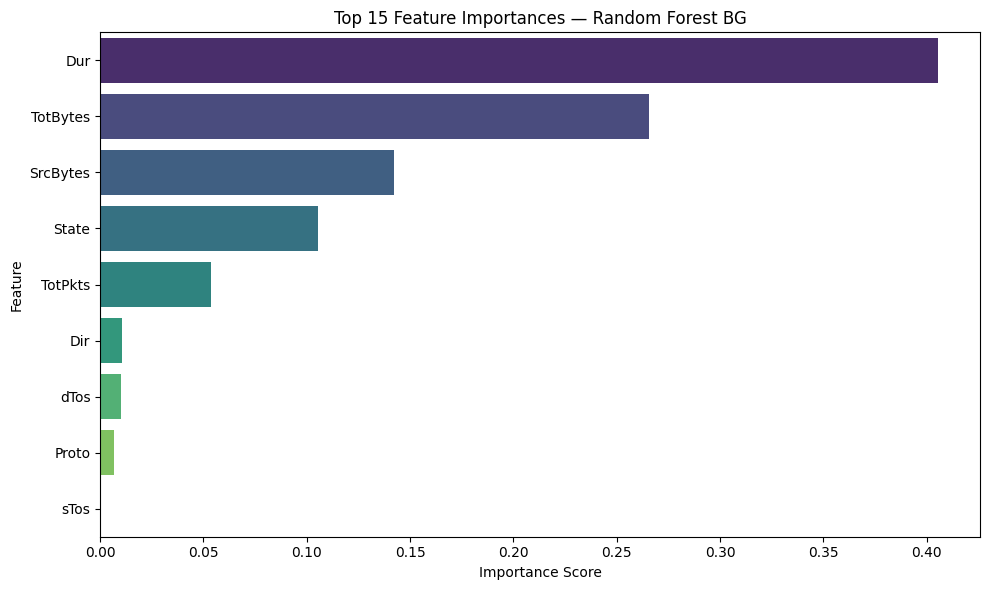

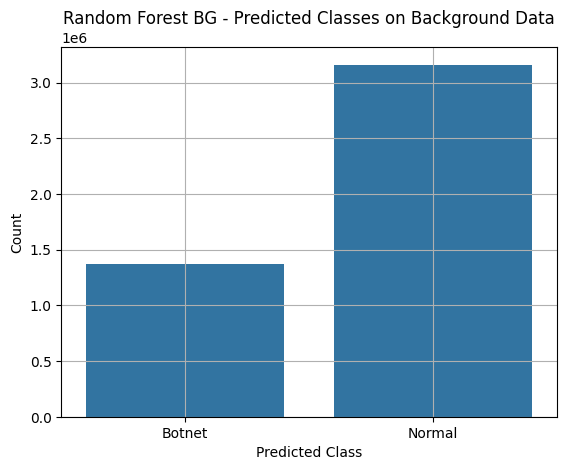

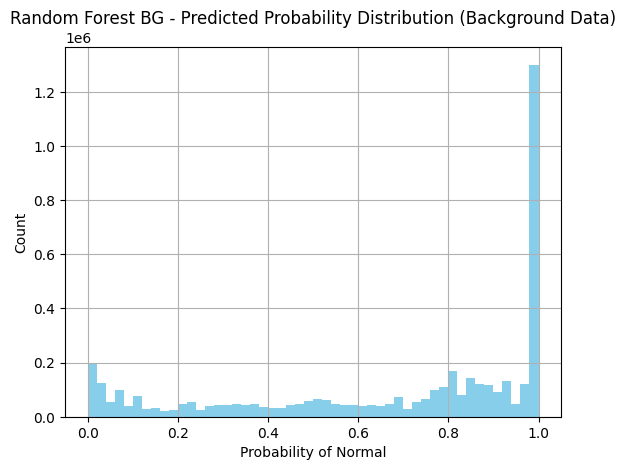

Predicted Botnet:
1371593
                Dur         Proto           Dir         State          sTos  \
count  1.371593e+06  1.371593e+06  1.371593e+06  1.371593e+06  1.366823e+06   
mean   1.914622e+02  1.257534e+01  2.064386e+00  6.147745e+01  3.764935e-03   
std    6.744397e+02  1.331121e+00  1.390549e+00  8.621076e+01  2.976676e-01   
min    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%    8.990000e-04  1.200000e+01  0.000000e+00  9.000000e+00  0.000000e+00   
50%    1.450000e-03  1.300000e+01  3.000000e+00  9.000000e+00  0.000000e+00   
75%    8.966370e-01  1.300000e+01  3.000000e+00  8.200000e+01  0.000000e+00   
max    3.600031e+03  1.400000e+01  6.000000e+00  2.640000e+02  1.920000e+02   

               dTos       TotPkts      TotBytes      SrcBytes  Predicted  \
count  1.198333e+06  1.371593e+06  1.371593e+06  1.371593e+06  1371593.0   
mean   5.332408e-04  1.741551e+01  1.494969e+04  6.083146e+02        0.0   
std    3.641051e-02  4.499408e+02 

c:\Users\PC\Desktop\CSC 516\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:53:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


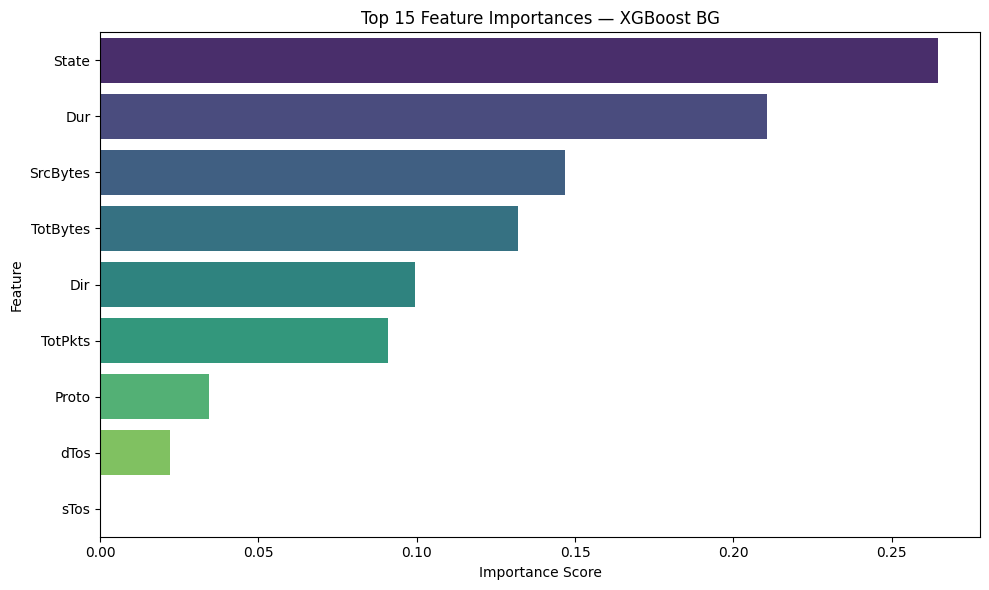

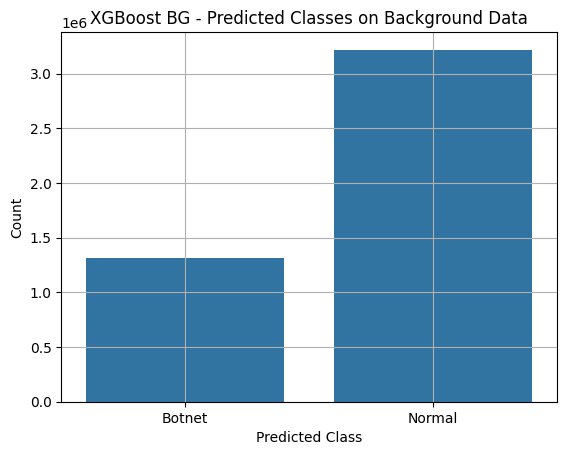

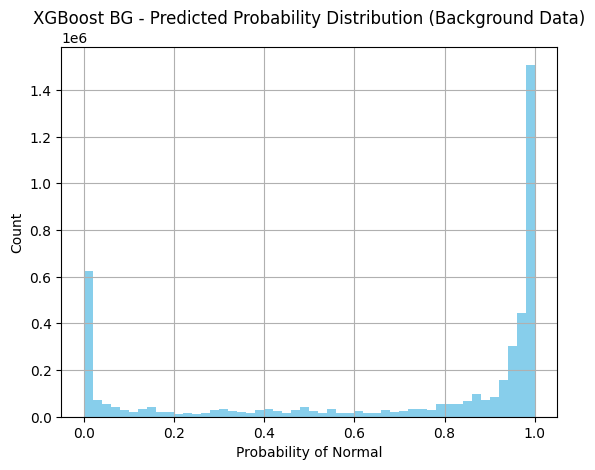

Predicted Botnet:
1312230
                Dur         Proto           Dir         State          sTos  \
count  1.312230e+06  1.312230e+06  1.312230e+06  1.312230e+06  1.307149e+06   
mean   6.087349e+01  1.249209e+01  1.996363e+00  6.524598e+01  9.424710e-02   
std    3.875943e+02  1.461486e+00  1.413293e+00  8.825040e+01  4.181337e+00   
min    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%    8.960000e-04  1.200000e+01  0.000000e+00  9.000000e+00  0.000000e+00   
50%    1.386000e-03  1.300000e+01  3.000000e+00  9.000000e+00  0.000000e+00   
75%    5.714475e-01  1.300000e+01  3.000000e+00  8.200000e+01  0.000000e+00   
max    3.600000e+03  1.400000e+01  6.000000e+00  2.640000e+02  1.920000e+02   

               dTos       TotPkts      TotBytes      SrcBytes  Predicted  \
count  1.160917e+06  1.312230e+06  1.312230e+06  1.312230e+06  1312230.0   
mean   4.315554e-04  4.729892e+01  4.474737e+04  3.518019e+03        0.0   
std    3.200008e-02  4.829205e+03 

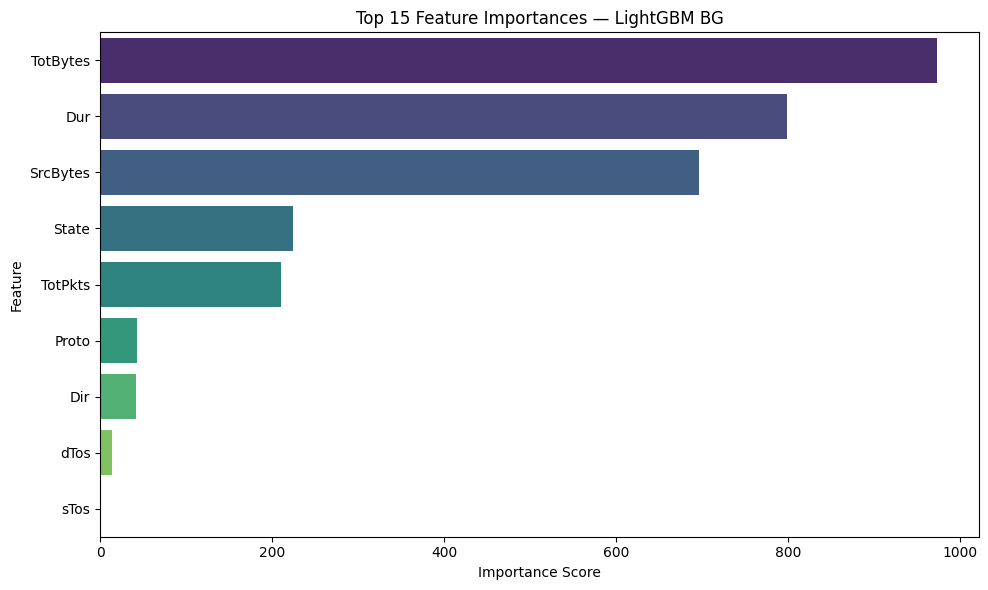

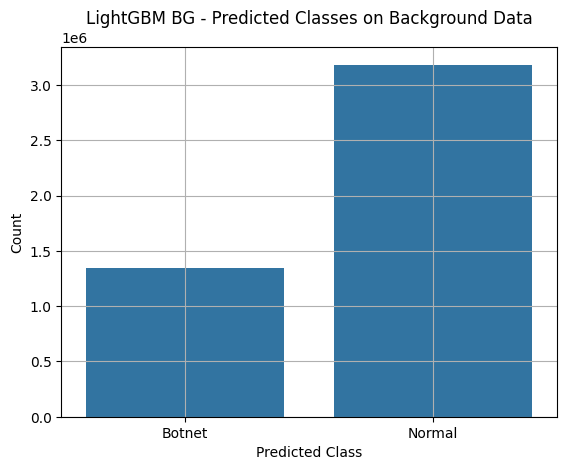

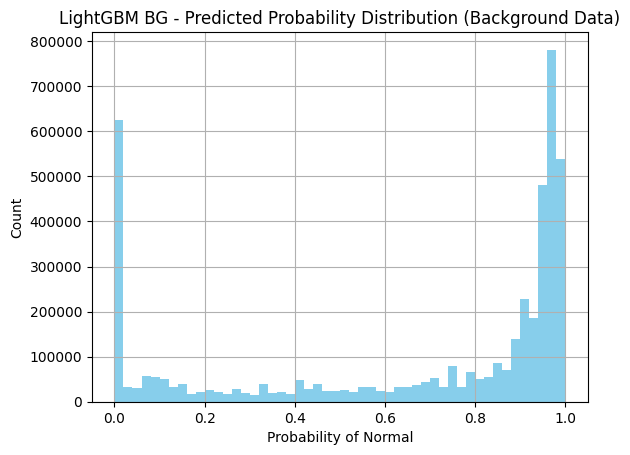

Predicted Botnet:
1348737
                Dur         Proto           Dir         State          sTos  \
count  1.348737e+06  1.348737e+06  1.348737e+06  1.348737e+06  1.342250e+06   
mean   7.998780e+01  1.243202e+01  2.031184e+00  6.487797e+01  9.188601e-02   
std    4.451088e+02  1.723321e+00  1.399683e+00  8.884211e+01  4.126362e+00   
min    0.000000e+00  3.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%    8.940000e-04  1.200000e+01  0.000000e+00  9.000000e+00  0.000000e+00   
50%    1.378000e-03  1.300000e+01  3.000000e+00  9.000000e+00  0.000000e+00   
75%    5.530250e-01  1.300000e+01  3.000000e+00  1.110000e+02  0.000000e+00   
max    3.600000e+03  1.400000e+01  5.000000e+00  2.650000e+02  1.920000e+02   

               dTos       TotPkts      TotBytes      SrcBytes  Predicted  \
count  1.168637e+06  1.348737e+06  1.348737e+06  1.348737e+06  1348737.0   
mean   4.475299e-04  1.781960e+01  1.530919e+04  6.458202e+02        0.0   
std    3.315678e-02  4.760580e+02 

In [7]:
# Prepare each model. BG for background
models = {
    'Random Forest BG': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost BG': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    'LightGBM BG': LGBMClassifier(random_state=42)
}

results = {}

# Loop to test each model
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    
    

    plot_feature_importance(model, name, X)

    
    # Save each model
    joblib.dump(model, f'models/{name.replace(" ", "_")}.joblib')

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # probability of "Normal" (or check with le)

    # Compare percentage of botnet vs. normal predictions 
    sns.countplot(x=y_pred)
    plt.title(f"{name} - Predicted Classes on Background Data")
    plt.xticks(ticks=[0, 1], labels=le.inverse_transform([0, 1]))
    plt.xlabel("Predicted Class")
    plt.ylabel("Count")
    plt.grid()
    plt.show()

    #  Histogram of confidence of predicted probabilities
    plt.hist(y_prob, bins=50, color='skyblue')
    plt.title(f"{name} - Predicted Probability Distribution (Background Data)")
    plt.xlabel("Probability of Normal")
    plt.ylabel("Count")
    plt.grid()
    plt.show()

    test_df['Predicted'] = y_pred
    test_df['Botnet_Prob'] = y_prob

    # Split between botnet and normal and print the descriptions for each
    predicted_botnet = test_df[test_df['Predicted'] == le.transform(['Botnet'])[0]]
    predicted_normal = test_df[test_df['Predicted'] == le.transform(['Normal'])[0]]

    print("Predicted Botnet:")
    print(len(predicted_botnet))
    print(predicted_botnet.describe())

    print("\nPredicted Normal:")
    print(len(predicted_normal))
    print(predicted_normal.describe())

 